In [1]:
import os
import glob
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
from IPython.display import display, HTML

from vip_slap2_analysis.voltage.extraction import load_voltage_roi_transform_h5
from vip_slap2_analysis.plotting.plot_session_heatmap import _robust_row_zscore
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.voltage.postprocess import concat_rois_across_trials
from vip_slap2_analysis.utils.utils import save_figure

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [9]:
%matplotlib inline

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures')

TARGET_MICE = [
    826031,
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#   voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"      # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 10 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,50,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [6]:
asset = assets[4]
print(asset.session_id)
print("session_dir:", asset.session_dir)
print("derived_dir:", asset.derived_dir)
print("voltage assets:")
for key, path in asset.get_modality_assets("voltage").items():
    print(f"  {key}: {path}")

826031_2026-02-04_12-15-34
session_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34
derived_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\analysis\derived
voltage assets:
  summary_mat: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34_slap2_2026-02-04_12-15-34\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260625-134608.mat
  trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34_slap2_2026-02-04_12-15-34\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260625-134608.h5
  extraction_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34_slap2_2026-02-04_12-15-34\source_extraction\dendriticVoltageExtraction


In [7]:
vs = VoltageSummary(asset.modality_assets['voltage']['summary_mat'])

Inspecting: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


<IPython.core.display.Javascript object>


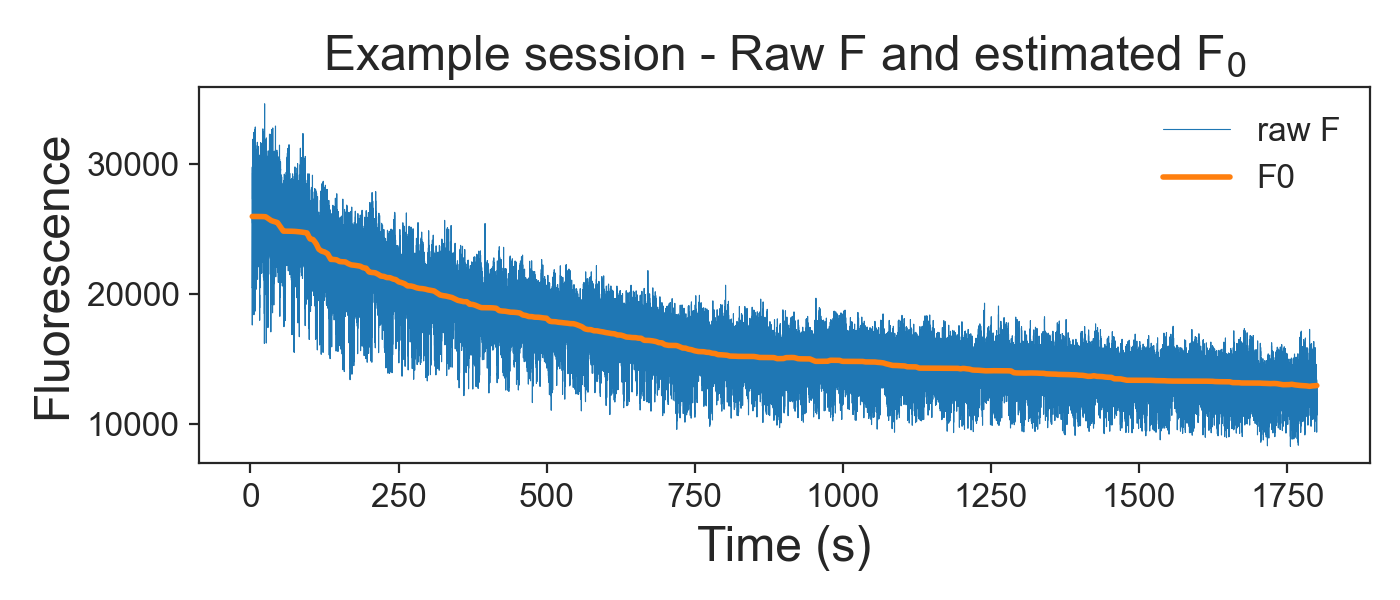

C:\Users\andrew.shelton\Anaconda3\lib\site-packages\fontTools\misc\py23.py:11: DeprecationWarning: The py23 module has been deprecated and will be removed in a future release. Please update your code.
  warnings.warn(


<IPython.core.display.Javascript object>


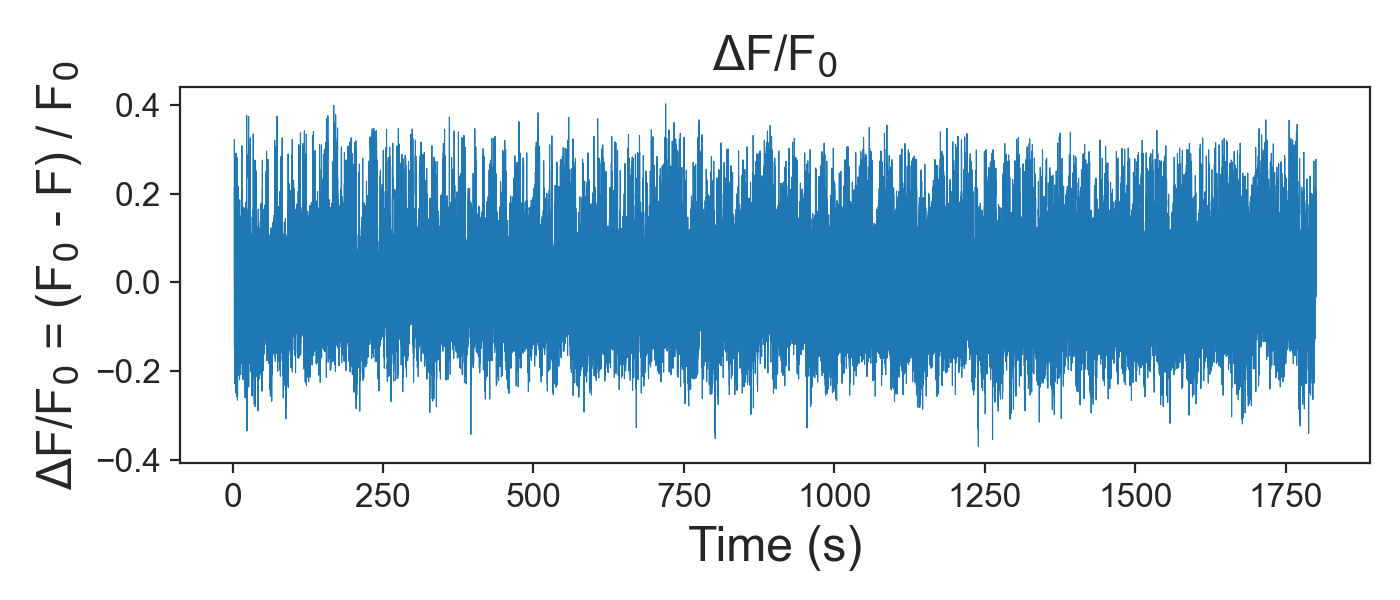

In [8]:
dmd = 1
roi_index = 0
trace_signal = "dff_robust_f0"

session_trace_h5 = asset.derived_dir / 'voltage' / 'voltage_session_traces_dff_robust_f0_trial.h5'
print("Inspecting:", session_trace_h5)

if not session_trace_h5.exists():
    print("Session trace H5 not found. Run voltage extraction first, or use the next cell to compute one ROI on the fly.")
else:
    roi = load_voltage_roi_transform_h5(session_trace_h5, dmd=dmd, roi_index=roi_index)
    t = roi["timebase_sec"]
    raw_f = roi["raw_f"]
    f0 = roi["f0"]
    dff = roi["dff"]
    window = (0,1800)

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    ax.plot(t[t<=window[1]], raw_f[t<=window[1]], lw=0.4, label="raw F")
    ax.plot(t[t<=window[1]], f0[t<=window[1]], lw=2.0, label="F0")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fluorescence")
    ax.set_title("Example session - Raw F and estimated F$_{0}$")
    ax.legend(frameon=False,fontsize=12)
    fig.tight_layout()
    filen = 'rawF_F0_example'
    save_figure(fig,os.path.join(SAVE_PATH,filen),formats = ['.pdf','.png'],dpi=300)
    
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    ax.plot(t[t<=window[1]], dff[t<=window[1]], lw=0.4)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("\u0394F/F$_{0}$ = (F$_{0}$ - F) / F$_{0}$")
    ax.set_title('\u0394F/F$_{0}$')
    fig.tight_layout()
    filen = 'dFF_example'
    save_figure(fig,os.path.join(SAVE_PATH,filen),formats = ['.pdf','.png'],dpi=300)

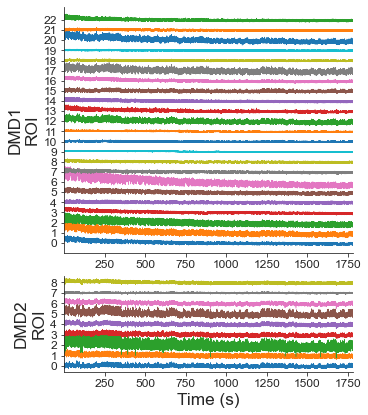

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

from vip_slap2_analysis.voltage.postprocess import concat_rois_across_trials


def _minmax_downsample_2d(X, sample_rate_hz=10_800, max_points=40_000):
    """
    X is time x ROI.
    Preserves the min/max envelope within temporal bins, much better than simple
    striding for voltage traces with brief excursions.
    """
    X = np.asarray(X)
    n_samples, n_rois = X.shape

    if n_samples <= max_points:
        return np.arange(n_samples, dtype=np.float64) / sample_rate_hz, X

    n_bins = max(1, max_points // 2)
    bin_size = max(1, n_samples // n_bins)
    n_use = (n_samples // bin_size) * bin_size

    Xb = X[:n_use].reshape(n_use // bin_size, bin_size, n_rois)

    ymin = np.nanmin(Xb, axis=1)
    ymax = np.nanmax(Xb, axis=1)

    xb = (
        np.arange(ymin.shape[0], dtype=np.float64) * bin_size
        + 0.5 * bin_size
    ) / sample_rate_hz

    x_plot = np.repeat(xb, 2)

    X_plot = np.empty((2 * ymin.shape[0], n_rois), dtype=np.float32)
    X_plot[0::2] = ymin
    X_plot[1::2] = ymax

    return x_plot, X_plot


def _robust_spacing(X_plot, overlap=0.90, min_spacing=1.0):
    """
    Data-driven vertical spacing. Smaller overlap gives more overlap;
    larger overlap gives more separation.
    """
    lo = np.nanpercentile(X_plot, 2, axis=0)
    hi = np.nanpercentile(X_plot, 98, axis=0)
    robust_ranges = hi - lo

    spacing = np.nanpercentile(robust_ranges, 90) * overlap

    if not np.isfinite(spacing) or spacing <= 0:
        spacing = min_spacing

    return max(float(spacing), float(min_spacing))


def plot_concatenated_voltage_rois(
    vs,
    *,
    dmds=(1, 2),
    sample_rate_hz=10_800,
    max_points=40_000,
    time_unit="min",        # "s" or "min"
    spacing=None,           # None = estimate separately per DMD
    overlap=0.90,
    center="median",        # "median", "mean", "first", or None
    drop_discarded=True,
    trace_mode="trial",
    dtype=np.float32,
    roi_height=0.22,        # inches per ROI
    min_axis_height=1.4,
    width=8.0,
    lw=0.45,
    rasterized=True,
):
    loaded = {}
    n_by_dmd = []

    for dmd in dmds:
        X, trial_slices = concat_rois_across_trials(
            vs,
            dmd=dmd,
            drop_discarded=drop_discarded,
            dtype=dtype,
            return_array=True,
            trace_mode=trace_mode,
        )

        # X is time x ROI.
        loaded[int(dmd)] = {
            "X": X,
            "trial_slices": trial_slices,
        }
        n_by_dmd.append(int(X.shape[1]))

    height_ratios = [max(1, n) for n in n_by_dmd]
    fig_height = sum(max(min_axis_height, roi_height * n) for n in n_by_dmd) + 0.8

    fig, axes = plt.subplots(
        len(dmds),
        1,
        figsize=(width, fig_height),
        sharex=True,
        gridspec_kw={"height_ratios": height_ratios},
        constrained_layout=True,
    )


    axes = np.atleast_1d(axes)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["k"])

    for ax, dmd, n_rois in zip(axes, dmds, n_by_dmd):
        X = loaded[int(dmd)]["X"]

        x_sec, Xp = _minmax_downsample_2d(
            X,
            sample_rate_hz=sample_rate_hz,
            max_points=max_points,
        )

        if time_unit.lower().startswith("min"):
            x = x_sec / 60
            xlabel = "Time (min)"
        else:
            x = x_sec
            xlabel = "Time (s)"

        if center is None:
            centers = np.zeros(n_rois, dtype=float)
        elif center == "median":
            centers = np.nanmedian(Xp, axis=0)
        elif center == "mean":
            centers = np.nanmean(Xp, axis=0)
        elif center == "first":
            centers = np.nanmean(Xp[:min(1000, Xp.shape[0])], axis=0)
        else:
            raise ValueError("center must be 'median', 'mean', 'first', or None")

        X_centered = Xp - centers

        this_spacing = spacing
        if this_spacing is None:
            this_spacing = _robust_spacing(X_centered, overlap=overlap)

        offsets = np.arange(n_rois, dtype=float) * float(this_spacing)

        segments = []
        colors = []

        for r in range(n_rois):
            y = X_centered[:, r] + offsets[r]
            segments.append(np.column_stack((x, y)))
            colors.append(color_cycle[r % len(color_cycle)])

        lc = LineCollection(
            segments,
            colors=colors,
            linewidths=lw,
            rasterized=rasterized,
        )

        ax.add_collection(lc)
        ax.autoscale_view()
        ax.margins(x=0, y=0.03)

        ax.set_yticks(offsets)
        ax.set_yticklabels(np.arange(n_rois))
        ax.set_ylabel(f"DMD{dmd}\nROI")

        ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
        ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].set_xlabel(xlabel)

    return fig, axes, loaded


fig, ax, loaded = plot_concatenated_voltage_rois(
    vs,
    dmds=(1, 2),
    sample_rate_hz=10_800,
    max_points=40_000,
    time_unit="sec",
    overlap=1,
    roi_height=0.15,
    width=5,
)

filen = "raw_example_fast_even_spacing"
save_figure(
    fig,
    os.path.join(SAVE_PATH, filen),
    formats=[".pdf", ".png"],
    dpi=300,
)